# Comprensión y Análisis Exploratorio de Datos (EDA)

Este notebook realiza el análisis exploratorio del dataset de solicitudes de crédito,
con el objetivo de comprender sus variables, detectar problemas de calidad de datos,
y sentar las bases para las etapas posteriores de feature engineering y modelado.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('../../Base_de_datos.csv', sep=';')
df.head()

,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,...,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,7,21/12/2024 11:31,3692160,10,42,Independiente,8000000,2500000,341296,"88,768094",...,0.0,51258.0,51258.0,0.0,5,0,0,908526.0,Estable,1
1,4,22/4/2025 09:47,840000,6,60,Empleado,3000000,2000000,124876,"95,227787",...,0.0,8673.0,8673.0,0.0,0,0,2,939017.0,Creciente,1
2,9,8/1/2026 12:22,5974028,10,36,Independiente,4036000,829000,529554,"47,613894",...,0.0,18702.0,18702.0,0.0,3,0,0,NaN,NaN,0
3,4,4/8/2025 12:04,1671240,6,48,Empleado,1524547,498000,252420,"95,227787",...,0.0,15782.0,15782.0,0.0,3,0,0,1536193.0,Creciente,1
4,9,26/4/2025 11:24,2781636,11,44,Empleado,5000000,4000000,217037,"95,227787",...,0.0,204804.0,204804.0,0.0,3,0,1,933473.0,Creciente,1


In [2]:
print("Dimensiones del dataset:", df.shape)
df.info()

Dimensiones del dataset: (10763, 23)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10763 entries, 0 to 10762
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   tipo_credito                   10763 non-null  int64  
 1   fecha_prestamo                 10763 non-null  object 
 2   capital_prestado               10763 non-null  int64  
 3   plazo_meses                    10763 non-null  int64  
 4   edad_cliente                   10763 non-null  int64  
 5   tipo_laboral                   10763 non-null  object 
 6   salario_cliente                10763 non-null  int64  
 7   total_otros_prestamos          10763 non-null  int64  
 8   cuota_pactada                  10763 non-null  int64  
 9   puntaje                        10763 non-null  object 
 10  puntaje_datacredito            10757 non-null  float64
 11  cant_creditosvigentes          10763 non-null  int64  
 12  huella_co

### Correccion de tipo de dato: columna `puntaje`
Al revisar la columna `puntaje`, se detecto que estaba cargada como tipo texto (`str`) en lugar de numérico. 
Se realiza el reemplazo de coma por punto y se convierte la columna a tipo `float` para poder utilizarla correctamente en los análisis estadísticos y en el modelado.

In [3]:
df['puntaje'].unique()[:20]

array(['88,768094', '95,227787', '47,613894', '49,161959', '46,387527',
       '-4,158836', '40,818275', '-11,093652', '89,2295', '58,597591',
       '84,730786', '-15,473246', '91,410695', '89,979287', '92,228643',
       '91,99794', '-13,193985', '-5,102625', '86,830187', '3,819022'],
      dtype=object)

In [4]:
df['puntaje'] = df['puntaje'].str.replace(',', '.').astype(float)
df['puntaje'].describe()

count    10763.000000
mean        91.170036
std         16.465441
min        -38.009990
25%         95.227787
50%         95.227787
75%         95.227787
max         95.227787
Name: puntaje, dtype: float64

In [5]:
print(df['puntaje'].describe())
print()
print("Cantidad de valores negativos:", (df['puntaje'] < 0).sum())
print("Porcentaje de valores negativos:", round((df['puntaje'] < 0).mean() * 100, 2), "%")

count    10763.000000
mean        91.170036
std         16.465441
min        -38.009990
25%         95.227787
50%         95.227787
75%         95.227787
max         95.227787
Name: puntaje, dtype: float64

Cantidad de valores negativos: 135
Porcentaje de valores negativos: 1.25 %


#### Nota: columna `puntaje`
Se corrige el tipo de dato (de texto a numérico). A revisar más adelante si aporta 
valor predictivo, dado que la mayoría de los registros comparten el mismo valor.

#### Revisamos nulls en el resto de columnas

In [6]:
df.isnull().sum().sort_values(ascending=False)

tendencia_ingresos               2932
promedio_ingresos_datacredito    2930
saldo_mora_codeudor               590
saldo_principal                   405
saldo_mora                        156
saldo_total                       156
puntaje_datacredito                 6
salario_cliente                     0
tipo_laboral                        0
edad_cliente                        0
plazo_meses                         0
capital_prestado                    0
fecha_prestamo                      0
tipo_credito                        0
total_otros_prestamos               0
cant_creditosvigentes               0
huella_consulta                     0
cuota_pactada                       0
puntaje                             0
creditos_sectorCooperativo          0
creditos_sectorFinanciero           0
creditos_sectorReal                 0
Pago_atiempo                        0
dtype: int64

Realizamos un revision rapida..

In [7]:
for col in df.columns:
    print(f"--- {col} ({df[col].dtype}) ---")
    print(df[col].unique()[:6])
    print()

--- tipo_credito (int64) ---
[ 7  4  9 10  6 68]

--- fecha_prestamo (object) ---
['21/12/2024 11:31' '22/4/2025 09:47' '8/1/2026 12:22' '4/8/2025 12:04'
 '26/4/2025 11:24' '10/6/2025 08:54']

--- capital_prestado (int64) ---
[3692160  840000 5974028 1671240 2781636 1031928]

--- plazo_meses (int64) ---
[10  6 11 12  3  8]

--- edad_cliente (int64) ---
[42 60 36 48 44 32]

--- tipo_laboral (object) ---
['Independiente' 'Empleado']

--- salario_cliente (int64) ---
[8000000 3000000 4036000 1524547 5000000 2800000]

--- total_otros_prestamos (int64) ---
[2500000 2000000  829000  498000 4000000  800000]

--- cuota_pactada (int64) ---
[341296 124876 529554 252420 217037  82872]

--- puntaje (float64) ---
[88.768094 95.227787 47.613894 49.161959 46.387527 -4.158836]

--- puntaje_datacredito (float64) ---
[695. 789. 740. 837. 771. 721.]

--- cant_creditosvigentes (int64) ---
[10  3  4 11  1  0]

--- huella_consulta (int64) ---
[ 5  1  4  6 13  8]

--- saldo_mora (float64) ---
[   0.  132.  36

##### Revisión exhaustiva de tipos de datos

Si bien la revisión inicial con `df.info()` permitió identificar qué columnas eran 
numericas y cuales de texto, se decide realizar una inspección más profunda de los 
valores únicos de cada columna. Esto con el objetivo de detectar inconsistencias que 
no son visibles a simple nivel de tipo de dato.

A continuación, se revisa cada columna en detalle, evaluando si el tipo de dato y los valores que contiene son coherentes con lo que la columna representa.

In [8]:
df['tendencia_ingresos'].value_counts()

tendencia_ingresos
Creciente      5294
Decreciente    1291
Estable        1188
0                 7
8315              6
1000000           4
9147              2
158042            1
168750            1
3978              1
-28589            1
-566272           1
24702             1
31837             1
122727            1
417087            1
9090              1
173031            1
-70715            1
-435177           1
-702927           1
-4105             1
54683             1
22832             1
209090            1
5697              1
10808             1
-288              1
-164315           1
2029000           1
17181             1
15245             1
82657             1
52862             1
1817052           1
75761             1
146918            1
1123000           1
15090             1
4250635           1
22363             1
-101368           1
86286             1
65988             1
77975             1
-224714           1
Name: count, dtype: int64

In [9]:
# Cuantos registros tienen un valor (no Creciente/Decreciente/Estable) en tendencia_ingresos
categorias_validas = ['Creciente', 'Decreciente', 'Estable']
filas_raras = df[~df['tendencia_ingresos'].isin(categorias_validas) & df['tendencia_ingresos'].notna()]
print("Cantidad de filas con valores raros:", len(filas_raras))
filas_raras[['tendencia_ingresos', 'promedio_ingresos_datacredito', 'salario_cliente']].head(25)

Cantidad de filas con valores raros: 58


,tendencia_ingresos,promedio_ingresos_datacredito,salario_cliente
157,8315,939017.0,4000000
168,0,1200000.0,5000000
440,158042,28878675.0,44707750
486,3978,1562215.0,6000000
705,9147,1000000.0,3100000
1185,8315,977131.0,2990000
1188,168750,2550000.0,2900000
1898,-28589,5425531.0,5000000
2027,8315,916148.0,1500000
2038,1000000,917014.0,1500000


Vamos a sumar los que son nulos..

In [10]:
df['tendencia_ingresos'].isnull().sum()

np.int64(2932)

In [11]:
categorias_validas = ['Creciente', 'Decreciente', 'Estable']
print(df[~df['tendencia_ingresos'].isin(categorias_validas) & df['tendencia_ingresos'].notna()].shape[0])

58


In [12]:
categorias_validas = ['Creciente', 'Decreciente', 'Estable']

nulos_originales = df['tendencia_ingresos'].isnull().sum()
valores_raros = df[~df['tendencia_ingresos'].isin(categorias_validas) & df['tendencia_ingresos'].notna()].shape[0]

print("Nulos originales:", nulos_originales)
print("Valores raros (no categoria valida):", valores_raros)
print("Total combinado (si se unifican):", nulos_originales + valores_raros)

Nulos originales: 2932
Valores raros (no categoria valida): 58
Total combinado (si se unifican): 2990


### Hallazgo: valores inconsistentes en `tendencia_ingresos`
Además de los 2.932 valores nulos detectados inicialmente, se identifican 58 registros adicionales con valores numéricos sin sentido categórico (ej: 8315, 0, 158042, -28589), que no corresponden a ninguna de las tres categorías esperadas `Creciente`, `Decreciente`, `Estable`.

Al comparar estos valores con columnas relacionadas `promedio_ingresos_datacredito`, 
`salario_cliente`, no se encuentra ninguna correlación numérica que permita 
reconstruir el dato original. Se interpreta que corresponden a un registro manual sin criterio claro por parte del operador, posiblemente por falta de informacion disponible al momento de la carga.

Esto eleva a 2.990 la cantidad de registros sin informacion confiable sobre la tendencia de ingresos del cliente. 
La decisión sobre cómo tratar estos casos (imputación, exclusión, o categoría "Desconocido") se abordará más adelante.

In [13]:
df['tendencia_ingresos'] = df['tendencia_ingresos'].fillna('Desconocido')

categorias_validas = ['Creciente', 'Decreciente', 'Estable']
df.loc[~df['tendencia_ingresos'].isin(categorias_validas), 'tendencia_ingresos'] = 'Desconocido'

In [14]:
df['tendencia_ingresos'].value_counts()

tendencia_ingresos
Creciente      5294
Desconocido    2990
Decreciente    1291
Estable        1188
Name: count, dtype: int64


Pago_atiempo → convertido a bool

puntaje → corregido (coma a punto, ahora float)

fecha_prestamo → pendiente de convertir a datetime

tendencia_ingresos → resuelto


##### Se realiza conversion de columnas 'fecha_prestamo' y 'Pago_atiempo'. Se le da el formato correspondiente. 

In [15]:
df['fecha_prestamo'] = pd.to_datetime(df['fecha_prestamo'], format='%d/%m/%Y %H:%M')

In [16]:
df['Pago_atiempo'] = df['Pago_atiempo'].astype(bool)

In [17]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10763 entries, 0 to 10762
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   tipo_credito                   10763 non-null  int64         
 1   fecha_prestamo                 10763 non-null  datetime64[ns]
 2   capital_prestado               10763 non-null  int64         
 3   plazo_meses                    10763 non-null  int64         
 4   edad_cliente                   10763 non-null  int64         
 5   tipo_laboral                   10763 non-null  object        
 6   salario_cliente                10763 non-null  int64         
 7   total_otros_prestamos          10763 non-null  int64         
 8   cuota_pactada                  10763 non-null  int64         
 9   puntaje                        10763 non-null  float64       
 10  puntaje_datacredito            10757 non-null  float64       
 11  cant_creditosvi

##### Revisamos otra columna 'tipo_laboral'

In [18]:
df['tipo_laboral'].head(10)

0    Independiente
1         Empleado
2    Independiente
3         Empleado
4         Empleado
5         Empleado
6    Independiente
7         Empleado
8         Empleado
9         Empleado
Name: tipo_laboral, dtype: object

In [19]:
df['tipo_laboral'].value_counts()

tipo_laboral
Empleado         6754
Independiente    4009
Name: count, dtype: int64

In [20]:
df['tipo_laboral'].value_counts(dropna=False)

tipo_laboral
Empleado         6754
Independiente    4009
Name: count, dtype: int64

#### tipo_credito 
Lo unico que tenemos columna tipo_credito con numeros (7, 4, 9, 10, 6, 68, etc.) — son codigos pero no tenemos el diccionario que traduce cada codigo a su significado real.

In [21]:
df['tipo_credito'].value_counts(dropna=False).sort_index()

tipo_credito
4     7747
6       21
7        2
9     2876
10     116
68       1
Name: count, dtype: int64

#### Distribucion de `tipo_credito`

Se identifican 6 códigos distintos, con una fuerte concentración en dos de ellos (código 4: 72% y código 9: 26.7% del dataset). Los codigos 6, 7, 10 y 68 representan casos minoritarios, destacando el código 68 con un único registro, lo cual podría indicar un caso atipico o un posible error de carga. Sin un diccionario de referencia no es posible confirmar esta hipotesis ni interpretar el significado de negocio de cada categoria.

In [22]:
df.describe()

,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,puntaje_datacredito,cant_creditosvigentes,huella_consulta,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito
count,10763.000000,10763,1.076300e+04,10763.000000,10763.000000,1.076300e+04,1.076300e+04,1.076300e+04,10763.000000,10757.000000,10763.000000,10763.000000,10607.000000,1.060700e+04,1.035800e+04,10173.000000,10763.000000,10763.000000,10763.000000,7.833000e+03
mean,5.411131,2025-04-16 23:05:32.851435520,2.434315e+06,10.575583,43.948620,1.721643e+07,6.238870e+06,2.436174e+05,91.170036,780.790834,5.726749,4.228561,7.746017,4.593741e+04,4.034617e+04,0.260002,2.779987,0.269813,1.302704,2.005157e+06
min,4.000000,2024-11-26 09:17:00,3.600000e+05,2.000000,19.000000,0.000000e+00,0.000000e+00,2.394400e+04,-38.009990,-7.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00
25%,4.000000,2025-01-20 17:32:30,1.224831e+06,6.000000,33.000000,2.000000e+06,5.000000e+05,1.210415e+05,95.227787,757.000000,3.000000,2.000000,0.000000,2.898000e+03,2.690000e+03,0.000000,1.000000,0.000000,0.000000,9.251570e+05
50%,4.000000,2025-03-27 16:23:00,1.921920e+06,10.000000,42.000000,3.000000e+06,1.000000e+06,1.828630e+05,95.227787,791.000000,5.000000,4.000000,0.000000,1.617800e+04,1.444250e+04,0.000000,2.000000,0.000000,1.000000,1.204496e+06
75%,9.000000,2025-06-16 13:27:30,3.084840e+06,12.000000,53.000000,4.875808e+06,2.000000e+06,2.878335e+05,95.227787,825.000000,8.000000,6.000000,0.000000,5.298200e+04,4.763225e+04,0.000000,4.000000,0.000000,2.000000,2.231859e+06
max,68.000000,2026-04-26 18:43:00,4.144415e+07,90.000000,123.000000,2.200000e+10,6.787675e+09,3.816752e+06,95.227787,999.000000,62.000000,29.000000,12534.000000,5.116066e+06,1.562285e+06,2145.000000,51.000000,13.000000,25.000000,3.810658e+07
std,2.338279,NaN,1.909643e+06,6.632082,15.060877,3.554767e+08,1.184183e+08,2.104937e+05,16.465441,104.878031,3.977162,3.064683,225.955117,1.062698e+05,7.124244e+04,21.772917,2.748807,0.716471,1.824430,2.144116e+06


In [23]:
df.head(10)   # las primeras 10 filas, tal cual están

,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,...,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,7,2024-12-21 11:31:00,3692160,10,42,Independiente,8000000,2500000,341296,88.768094,...,0.0,51258.0,51258.0,0.0,5,0,0,908526.0,Estable,True
1,4,2025-04-22 09:47:00,840000,6,60,Empleado,3000000,2000000,124876,95.227787,...,0.0,8673.0,8673.0,0.0,0,0,2,939017.0,Creciente,True
2,9,2026-01-08 12:22:00,5974028,10,36,Independiente,4036000,829000,529554,47.613894,...,0.0,18702.0,18702.0,0.0,3,0,0,NaN,Desconocido,False
3,4,2025-08-04 12:04:00,1671240,6,48,Empleado,1524547,498000,252420,95.227787,...,0.0,15782.0,15782.0,0.0,3,0,0,1536193.0,Creciente,True
4,9,2025-04-26 11:24:00,2781636,11,44,Empleado,5000000,4000000,217037,95.227787,...,0.0,204804.0,204804.0,0.0,3,0,1,933473.0,Creciente,True
5,4,2025-06-10 08:54:00,1031928,12,32,Empleado,2800000,800000,82872,95.227787,...,0.0,24399.0,24399.0,0.0,2,0,8,2808474.0,Creciente,True
6,4,2025-08-09 13:00:00,3064280,6,68,Independiente,1000000,22005000,461231,95.227787,...,0.0,211775.0,211775.0,0.0,6,3,0,969508.0,Creciente,True
7,4,2025-08-18 12:49:00,3619560,6,31,Empleado,3782303,305000,542079,95.227787,...,0.0,12078.0,12078.0,0.0,0,1,0,3782303.0,Creciente,True
8,9,2025-05-30 09:11:00,2134828,10,31,Empleado,14500000,8000000,181732,95.227787,...,0.0,0.0,NaN,NaN,0,0,0,14007850.0,Creciente,True
9,4,2024-12-31 14:32:00,8400000,6,45,Empleado,14000000,5000000,1166667,95.227787,...,0.0,125383.0,125383.0,0.0,2,0,0,28889623.0,Creciente,True


In [24]:
df.sample(10)  # 10 filas al azar

,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,...,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
9384,4,2024-12-28 16:25:00,1680000,8,28,Empleado,2400000,500000,190935,95.227787,...,0.0,60000.0,60000.0,0.0,0,0,1,1854545.0,Creciente,True
7077,9,2024-12-20 11:57:00,5096528,10,122,Empleado,3278000,3200000,467390,95.227787,...,NaN,NaN,NaN,NaN,0,0,0,NaN,Desconocido,True
9974,4,2024-12-05 11:43:00,770280,8,31,Empleado,1500000,700000,87366,95.227787,...,0.0,13449.0,13449.0,0.0,2,1,3,1014485.0,Creciente,True
3814,4,2025-01-03 13:16:00,1320000,6,44,Empleado,2200000,1000000,196234,95.227787,...,0.0,5567.0,5567.0,0.0,1,0,1,2070000.0,Estable,True
7179,9,2025-02-24 09:37:00,1544227,10,21,Empleado,1500000,300000,131112,95.227787,...,0.0,444.0,444.0,0.0,1,0,0,923771.0,Creciente,True
7576,4,2025-04-25 18:39:00,3350580,6,25,Empleado,4000000,2000000,497653,95.227787,...,0.0,6506.0,6506.0,0.0,2,0,3,1141473.0,Decreciente,True
130,4,2025-01-23 10:23:00,960000,6,62,Independiente,3000000,1050000,142489,95.227787,...,0.0,42809.0,40976.0,0.0,6,0,2,NaN,Desconocido,True
85,9,2025-02-08 11:44:00,1183716,9,62,Independiente,3500000,2000000,110549,95.227787,...,0.0,18080.0,18080.0,0.0,1,0,2,NaN,Desconocido,True
5163,9,2025-06-13 11:20:00,6630004,9,40,Independiente,4000000,2200000,621261,95.227787,...,0.0,9248.0,9248.0,0.0,0,2,2,946640.0,Creciente,True
4888,9,2025-08-13 11:33:00,2655456,7,47,Independiente,908526,7653000,314563,95.227787,...,0.0,39427.0,39427.0,0.0,6,0,1,961885.0,Creciente,True


## Análisis Univariable

A continuación se analiza la distribución de las variables numéricas más relevantes de forma individual, mediante histogramas, boxplots y estadísticas descriptivas. 
Esto permite identificar la forma de la distribución de cada variable, posibles valores atípicos (outliers) y entender mejor el comportamiento general de los datos antes de avanzar al análisis bivariable.

### Distribución de `edad_cliente`
Se analiza la edad de los clientes para entender el rango etario predominante en la cartera de creditos.

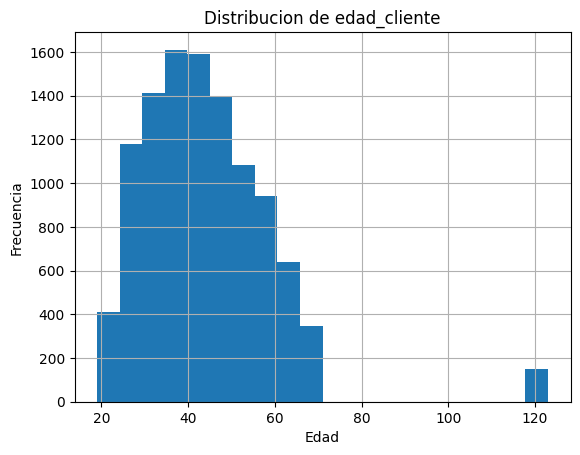

In [25]:
df['edad_cliente'].hist(bins=20)
plt.title('Distribucion de edad_cliente')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

detectamos anomalia

In [26]:
df[df['edad_cliente'] > 90]['edad_cliente'].value_counts()

edad_cliente
122    144
121      4
123      2
Name: count, dtype: int64

In [27]:
df[df['edad_cliente'] > 90][['edad_cliente', 'fecha_prestamo', 'tipo_laboral', 'salario_cliente', 'Pago_atiempo']].head(20)

,edad_cliente,fecha_prestamo,tipo_laboral,salario_cliente,Pago_atiempo
7008,122,2025-07-13 16:02:00,Empleado,38062010,True
7009,122,2025-04-16 17:06:00,Empleado,125078024,True
7010,122,2025-05-24 15:22:00,Empleado,9858473,True
7011,122,2025-04-12 10:34:00,Empleado,200000000,True
7012,122,2025-03-21 12:36:00,Empleado,5680147,True
7013,122,2025-06-13 14:58:00,Empleado,29965623,True
7014,122,2025-07-20 12:12:00,Empleado,13258352050,True
7015,122,2025-03-08 13:01:00,Empleado,535237000,False
7016,122,2025-11-02 12:17:00,Empleado,160806342,True
7017,122,2025-06-12 15:57:00,Empleado,95985077,True


In [28]:
casos_raros = df[df['edad_cliente'] > 90]
print("Tipo laboral en casos con edad > 90:")
print(casos_raros['tipo_laboral'].value_counts())

Tipo laboral en casos con edad > 90:
tipo_laboral
Empleado    150
Name: count, dtype: int64


### Hallazgo: valores de edad imposibles en `edad_cliente`

Se detectan 150 registros (1.4% del dataset) con edades de 121, 122 y 123 años, biologicamente imposibles. Al investigar estos casos, se confirma que el 100% de ellos corresponden a clientes con `tipo_laboral = 'Empleado'`, lo que sugiere un error sistematico en el proceso de carga de datos especifico para este segmento y no errores aislados o aleatorios.

Se decide tratar estos 150 valores como nulos, dado que no es posible inferir la edad real a partir de otras columnas disponibles.

In [29]:
df.loc[df['edad_cliente'] > 90, 'edad_cliente'] = np.nan

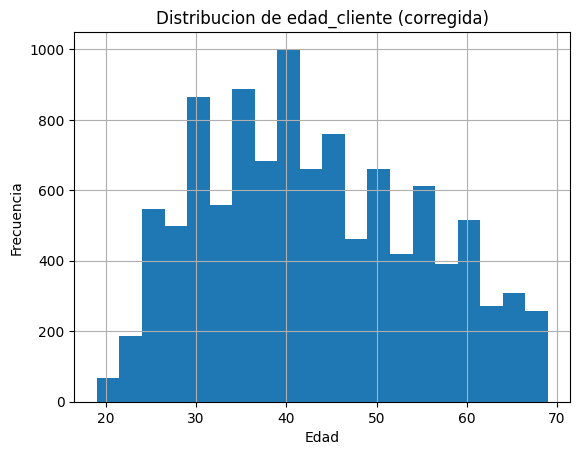

In [30]:
df['edad_cliente'].hist(bins=20)
plt.title('Distribucion de edad_cliente (corregida)')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

Tras corregir los valores imposibles, la distribucion de `edad_cliente` muestra una concentracion entre los 30 y 50 años, con pico cercano a los 40, y una disminución gradual hacia los extremos (20 y 70 años).

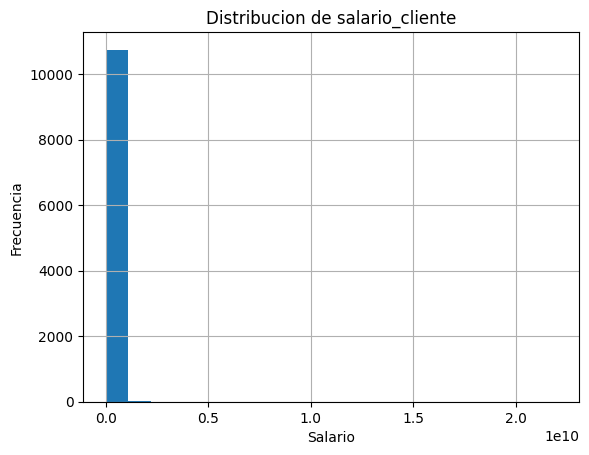

In [31]:
df['salario_cliente'].hist(bins=20)
plt.title('Distribucion de salario_cliente')
plt.xlabel('Salario')
plt.ylabel('Frecuencia')
plt.show()

Otra anomalia encontrada.. 

In [32]:
df.nlargest(18, 'salario_cliente')[['salario_cliente', 'tipo_laboral', 'capital_prestado', "edad_cliente"]]

,salario_cliente,tipo_laboral,capital_prestado,edad_cliente
5735,22000000000,Independiente,6480000,44.0
2866,16991100000,Empleado,2039761,69.0
7014,13258352050,Empleado,1411468,NaN
7043,12450806583,Empleado,6553657,NaN
7041,8252584000,Empleado,1131320,NaN
7070,7170914725,Empleado,9554640,NaN
7053,4857353453,Empleado,7235408,NaN
7116,4663274549,Empleado,4193428,NaN
7110,4067140000,Empleado,7490102,NaN
7058,3979311000,Empleado,4290198,NaN


In [33]:
print("Total de filas con salario > 1.000.000.000 (mil millones):")
print(df[df['salario_cliente'] > 1_000_000_000].shape[0])

print()
print("Tipo laboral de esos casos:")
print(df[df['salario_cliente'] > 1_000_000_000]['tipo_laboral'].value_counts())

Total de filas con salario > 1.000.000.000 (mil millones):
22

Tipo laboral de esos casos:
tipo_laboral
Empleado         21
Independiente     1
Name: count, dtype: int64


In [34]:
df[(df.index >= 7000) & (df.index <= 7150)]['capital_prestado'].describe()

count    1.510000e+02
mean     5.688968e+06
std      5.403603e+06
min      8.810760e+05
25%      2.858634e+06
50%      4.389823e+06
75%      6.737528e+06
max      4.144415e+07
Name: capital_prestado, dtype: float64

In [35]:
df[~((df.index >= 7000) & (df.index <= 7150))]['capital_prestado'].describe()

count    1.061200e+04
mean     2.388004e+06
std      1.770023e+06
min      3.600000e+05
25%      1.215231e+06
50%      1.903920e+06
75%      3.042780e+06
max      2.880000e+07
Name: capital_prestado, dtype: float64

### Decisión: eliminacion de bloque de registros corruptos

Se identifica un bloque de 151 registros consecutivos (índices ~7000-7150) que presenta valores sistematicamente inconsistentes en multiples columnas: edades imposibles (121-123 años), salarios desproporcionados (hasta $13.000 millones) y montos de capital prestado fuera del rango habitual del resto del dataset.

Dado que el problema afecta a la fila completa y no a una columna aislada, se decide eliminar estos 151 registros en lugar de imputar valores individuales  ya que no representan información confiable y su origen parece ser un error sistematico del proceso de carga de datos, no variabilidad real de los datos.

(Quedarse con todas las filas del dataset, excepto las que tengan un índice entre 7000 y 7150.)

In [36]:
df = df[~((df.index >= 7000) & (df.index <= 7150))]
print("Nuevo total de filas:", df.shape[0])

Nuevo total de filas: 10612


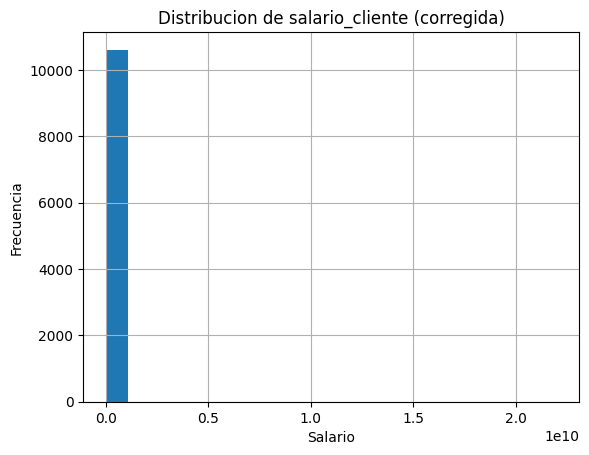

In [37]:
df['salario_cliente'].hist(bins=20)
plt.title('Distribucion de salario_cliente (corregida)')
plt.xlabel('Salario')
plt.ylabel('Frecuencia')
plt.show()

In [38]:
df.nlargest(10, 'salario_cliente')[['salario_cliente', 'tipo_laboral', 'edad_cliente']]

,salario_cliente,tipo_laboral,edad_cliente
5735,22000000000,Independiente,44.0
2866,16991100000,Empleado,69.0
9832,1035000000,Empleado,32.0
7155,970534000,Empleado,NaN
7156,300000000,Empleado,NaN
7152,200000000,Empleado,NaN
4995,154014666,Empleado,65.0
7436,120000000,Independiente,35.0
7153,105912527,Empleado,NaN
5521,80000000,Independiente,46.0


In [39]:
# Buscamos TODAS las filas con edad imposible (ya las pusimos en NaN, pero podemos buscar por salario alto en esa zona)
filas_problema = df[(df.index >= 6900) & (df.index <= 7200) & (df['salario_cliente'] > 100_000_000)]
print(filas_problema.index.min(), filas_problema.index.max())
print(filas_problema.shape[0])

7152 7156
4


In [40]:
print("Filas actuales con edad_cliente nula:", df['edad_cliente'].isna().sum())

Filas actuales con edad_cliente nula: 7


In [41]:
df[df['edad_cliente'].isna()]

,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,...,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
7151,9,2025-05-10 12:54:00,1608882,10,NaN,Empleado,36242000,33560000,136816,95.227787,...,NaN,NaN,NaN,NaN,0,0,0,NaN,Desconocido,True
7152,9,2025-02-09 17:42:00,2537442,10,NaN,Empleado,200000000,40000000,215214,84.730786,...,NaN,NaN,NaN,NaN,0,0,0,NaN,Desconocido,True
7153,9,2025-06-14 18:40:00,8005700,10,NaN,Empleado,105912527,75500000,681503,95.227787,...,NaN,NaN,NaN,NaN,0,0,0,NaN,Desconocido,True
7154,9,2025-02-21 15:31:00,976728,9,NaN,Empleado,50000000,0,91305,-16.250449,...,NaN,NaN,NaN,NaN,0,0,0,NaN,Desconocido,False
7155,9,2025-05-30 15:38:00,6613240,9,NaN,Empleado,970534000,0,619690,91.728786,...,NaN,NaN,NaN,NaN,0,0,0,NaN,Desconocido,True
7156,4,2025-05-04 16:05:00,9216000,6,NaN,Empleado,300000000,0,1373478,95.227787,...,NaN,NaN,NaN,NaN,0,0,0,NaN,Desconocido,True
7157,9,2025-05-05 10:17:00,10344990,11,NaN,Empleado,18797110,18611000,875855,95.227787,...,NaN,NaN,NaN,NaN,0,0,0,NaN,Desconocido,True


##### Patron compartido en estas 7 filas. Todas tienen exactamente las mismas caracteristicas "vacias" o repetidas:

-edad_cliente: vacío (NaN)

-tipo_laboral: Empleado (las 7, sin excepcion)

-puntaje_datacredito: 0.0 (las 7)

-cant_creditosvigentes: 0 (las 7)

-huella_consulta: 0 (las 7)

-saldo_mora, saldo_total, saldo_principal, saldo_mora_codeudor: vacios (las 7)

-creditos_sectorFinanciero/Cooperativo/Real: 0 (las 7)

-promedio_ingresos_datacredito: vacío (las 7)

-tendencia_ingresos: Desconocido (las 7)


Y de nuevo varios 'salario_cliente' exageradamente altos (200 millones, 970 millones, 300 millones...)

### Decision Razonable

Mismo criterio que con el bloque grande: estas 7 filas no representan datos confiables (fila completa afectada, no solo una columna) → se eliminan.

In [42]:
df = df[~df['edad_cliente'].isna()]
print("Nuevo total de filas:", df.shape[0])

Nuevo total de filas: 10605


### Actualizacion: casos adicionales de registros corruptos

Tras eliminar el bloque principal de 151 registros, se detectaron 7 casos adicionales con el mismo patron de corrupcion (edad nula, multiples columnas relacionadas a Datacrédito en cero, salarios desproporcionados). Se aplica el mismo criterio y se eliminan llevando el total de eliminados a 158 (1.5% del dataset original).

**Dataset final tras la limpieza: 10.605 registros.**

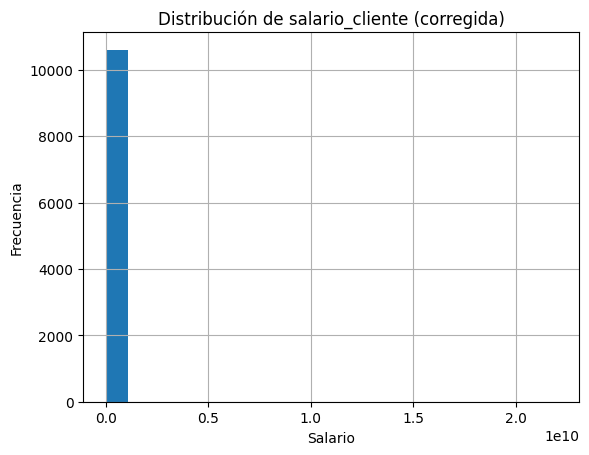

In [43]:
df['salario_cliente'].hist(bins=20)
plt.title('Distribución de salario_cliente (corregida)')
plt.xlabel('Salario')
plt.ylabel('Frecuencia')
plt.show()

In [44]:
df.nlargest(5, 'salario_cliente')[['salario_cliente', 'tipo_laboral', 'edad_cliente', 'capital_prestado']]

,salario_cliente,tipo_laboral,edad_cliente,capital_prestado
5735,22000000000,Independiente,44.0,6480000
2866,16991100000,Empleado,69.0,2039761
9832,1035000000,Empleado,32.0,907200
4995,154014666,Empleado,65.0,5128487
7436,120000000,Independiente,35.0,3144000


In [45]:
df.loc[[5735, 2866, 9832, 4995, 7436], ['salario_cliente', 'capital_prestado', 'cuota_pactada', 'plazo_meses']]

,salario_cliente,capital_prestado,cuota_pactada,plazo_meses
5735,22000000000,6480000,963113,6
2866,16991100000,2039761,141650,12
9832,1035000000,907200,70948,12
4995,154014666,5128487,437718,10
7436,120000000,3144000,468556,6


ajustamos..

In [46]:
df.loc[df['salario_cliente'] > 10_000_000_000, 'salario_cliente'] = np.nan
print("Casos afectados:", df['salario_cliente'].isna().sum())

Casos afectados: 2


### Outliers en salario_cliente

Se detectan 5 salarios muy altos (120 millones a 22.000 millones). Al comparar con el capital prestado y la cuota pactada, los dos casos mas extremos (17.000 y 22.000 millones) resultan incoherentes y se convierten a nulo.

Los otros 3 se mantienen, ya que podrian corresponder a clientes con ingresos altos reales.

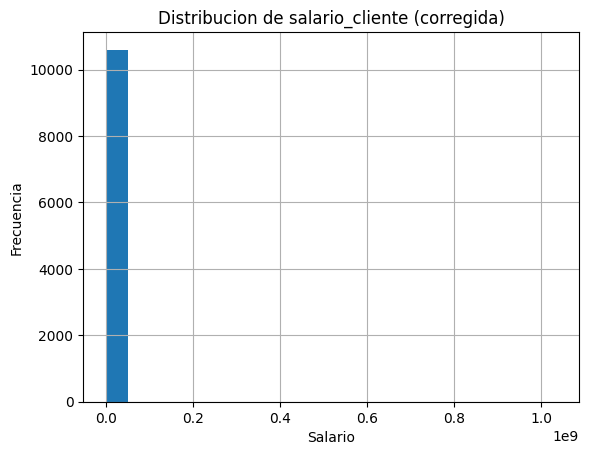

In [47]:
df['salario_cliente'].hist(bins=20)
plt.title('Distribucion de salario_cliente (corregida)')
plt.xlabel('Salario')
plt.ylabel('Frecuencia')
plt.show()

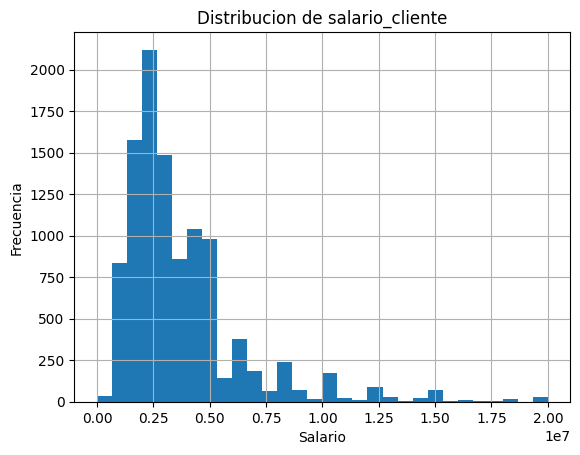

In [48]:
df['salario_cliente'].hist(bins=30, range=(0, 20_000_000))
plt.title('Distribucion de salario_cliente')
plt.xlabel('Salario')
plt.ylabel('Frecuencia')
plt.show()

### Distribucion de salario_cliente

Se limita la vista del histograma al rango 0-20 millones para visualizar mejor la distribucion principal, sin que los valores altos (mantenidos en el dataset) afecten la escala del grafico.

In [49]:
df['capital_prestado'].describe()

count    1.060500e+04
mean     2.385874e+06
std      1.766287e+06
min      3.600000e+05
25%      1.215204e+06
50%      1.903639e+06
75%      3.042358e+06
max      2.880000e+07
Name: capital_prestado, dtype: float64

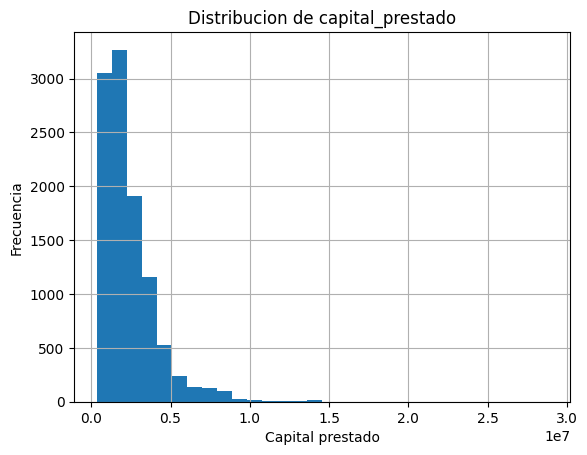

In [50]:
df['capital_prestado'].hist(bins=30)
plt.title('Distribucion de capital_prestado')
plt.xlabel('Capital prestado')
plt.ylabel('Frecuencia')
plt.show()

### Distribucion de capital_prestado

La mayoria de los creditos se concentran entre 0 y 5 millones, con un pico cercano a 1.5-2 millones. Distribucion con cola larga hacia montos mas altos, sin necesidad de ajustar la escala del grafico.

In [51]:
df['cuota_pactada'].describe()

count    1.060500e+04
mean     2.385256e+05
std      1.977910e+05
min      2.394400e+04
25%      1.205680e+05
50%      1.811400e+05
75%      2.828620e+05
max      2.671342e+06
Name: cuota_pactada, dtype: float64

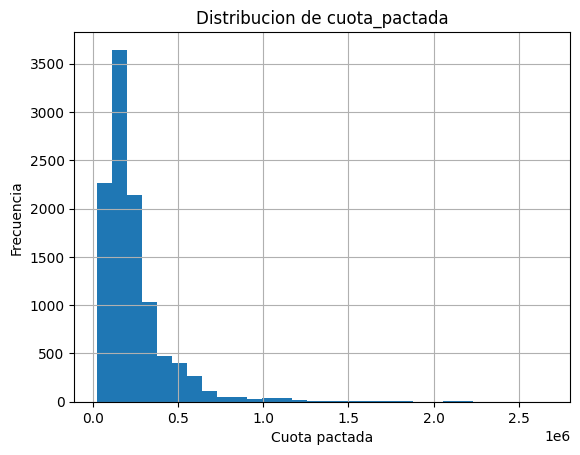

In [52]:
df['cuota_pactada'].hist(bins=30)
plt.title('Distribucion de cuota_pactada')
plt.xlabel('Cuota pactada')
plt.ylabel('Frecuencia')
plt.show()

### Distribucion de cuota_pactada

Concentracion entre 0 y 300 mil, con pico cercano a 150-200 mil. Distribucion similar a capital_prestado, lo cual es esperable dado que la cuota se calcula en base al capital y plazo del credito.

In [53]:
df['plazo_meses'].value_counts(dropna=False).sort_index()

plazo_meses
2      170
3      103
4       64
5      219
6     3320
7       21
8      524
9      602
10    1466
11     308
12    2652
18     275
20      14
24     463
30      18
36     384
48       1
90       1
Name: count, dtype: int64

observamos la cantidad solicitada para los plazos de 90 y 48 meses..

In [54]:
df[df['plazo_meses'].isin([48, 90])][['plazo_meses', 'capital_prestado', 'cuota_pactada', 'salario_cliente']]

,plazo_meses,capital_prestado,cuota_pactada,salario_cliente
8029,90,12542263,212394,0.0
8903,48,2822824,49007,2800000.0


In [55]:
print("Cantidad de clientes con salario_cliente = 0:", (df['salario_cliente'] == 0).sum())

Cantidad de clientes con salario_cliente = 0: 24


In [56]:
df[df['salario_cliente'] == 0][['tipo_laboral', 'capital_prestado', 'cuota_pactada', 'plazo_meses', 'Pago_atiempo']]

,tipo_laboral,capital_prestado,cuota_pactada,plazo_meses,Pago_atiempo
74,Empleado,677718,57390,10,True
289,Independiente,1459978,123634,10,True
320,Empleado,840000,126436,6,True
392,Independiente,3424415,290443,10,True
461,Empleado,1843218,149806,12,True
462,Independiente,2414822,225200,9,True
1057,Independiente,2311031,195440,11,True
1405,Empleado,2030038,172359,10,True
1486,Independiente,964020,113978,7,True
2864,Empleado,6529003,608877,9,True


### Casos con salario_cliente = 0

Se detectan 24 registros con salario en cero, sin patron de error sistemico (tipo laboral mixto, montos de credito razonables, pago a tiempo casi perfecto). Se interpreta como casos de ingresos no declarados formalmente, y se mantienen sin modificar, dado que no hay evidencia de corrupcion de datos.

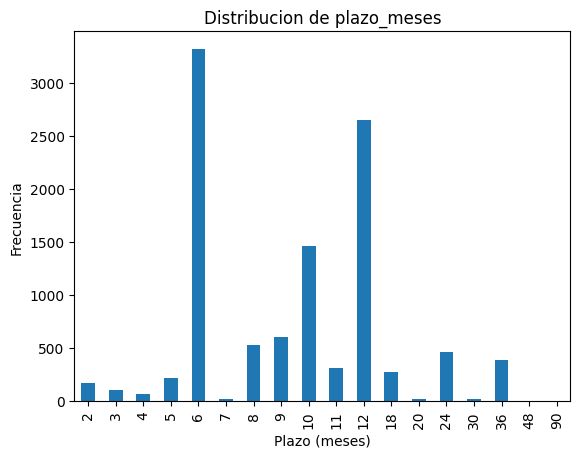

In [57]:
df['plazo_meses'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribucion de plazo_meses')
plt.xlabel('Plazo (meses)')
plt.ylabel('Frecuencia')
plt.show()

### Distribucion de plazo_meses

Se observan tres plazos predominantes: 6, 12 y 10 meses, que concentran la mayoria de los creditos otorgados.
El resto de los plazos son casos minoritarios.

In [58]:
df['cant_creditosvigentes'].value_counts().sort_index()

cant_creditosvigentes
0      256
1      636
2     1047
3     1203
4     1395
5     1259
6     1119
7      867
8      770
9      560
10     406
11     290
12     210
13     166
14     101
15      78
16      46
17      45
18      30
19      22
20      16
21      20
22      12
23       8
24       6
25       7
26      10
27       4
28       1
29       2
30       2
31       2
32       2
33       1
34       1
35       2
36       1
38       1
62       1
Name: count, dtype: int64

In [59]:
df[df['cant_creditosvigentes'] == 62][['tipo_laboral', 'salario_cliente', 'capital_prestado', 'Pago_atiempo', 'edad_cliente']]

,tipo_laboral,salario_cliente,capital_prestado,Pago_atiempo,edad_cliente
5489,Empleado,3800000.0,1141043,True,47.0


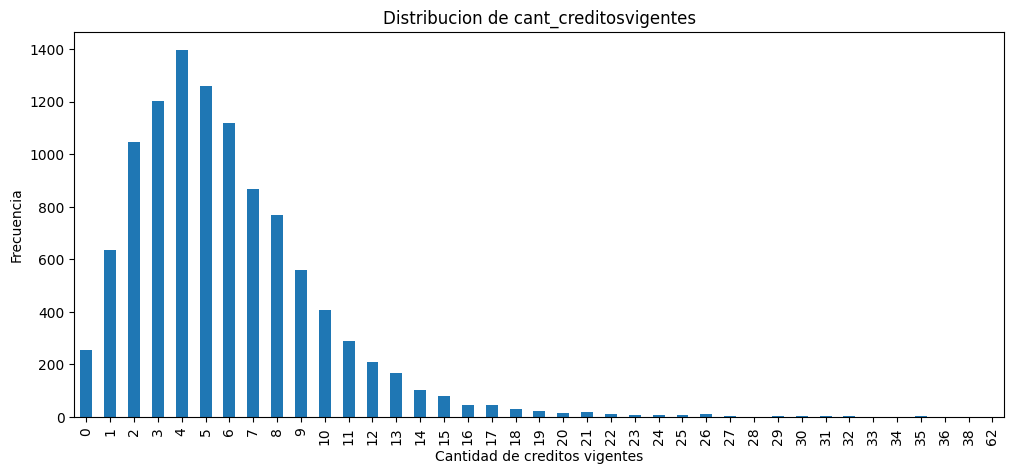

In [60]:
df['cant_creditosvigentes'].value_counts().sort_index().plot(kind='bar', figsize=(12,5))
plt.title('Distribucion de cant_creditosvigentes')
plt.xlabel('Cantidad de creditos vigentes')
plt.ylabel('Frecuencia')
plt.show()

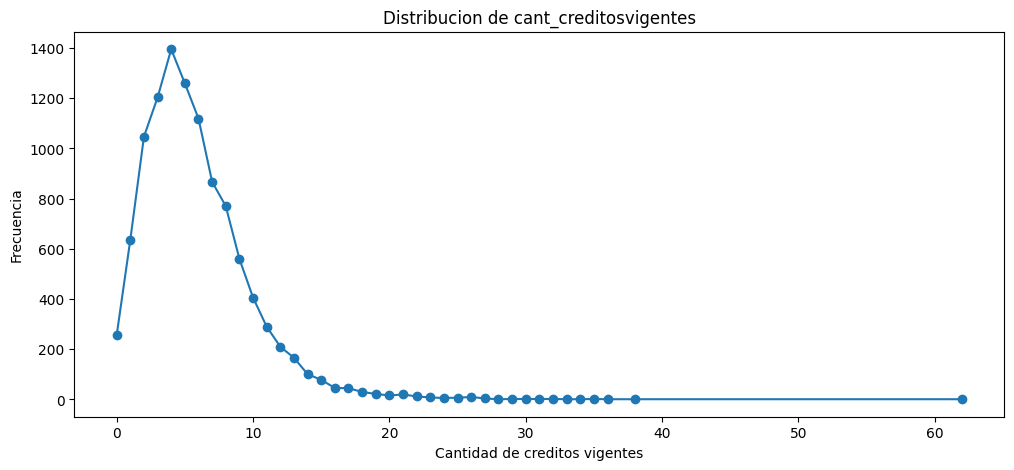

In [61]:
df['cant_creditosvigentes'].value_counts().sort_index().plot(kind='line', marker='o', figsize=(12,5))
plt.title('Distribucion de cant_creditosvigentes')
plt.xlabel('Cantidad de creditos vigentes')
plt.ylabel('Frecuencia')
plt.show()

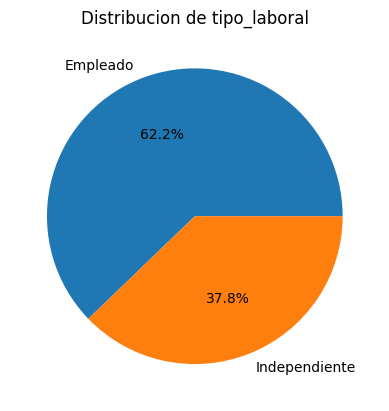

In [62]:
df['tipo_laboral'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Distribucion de tipo_laboral')
plt.ylabel('')
plt.show()

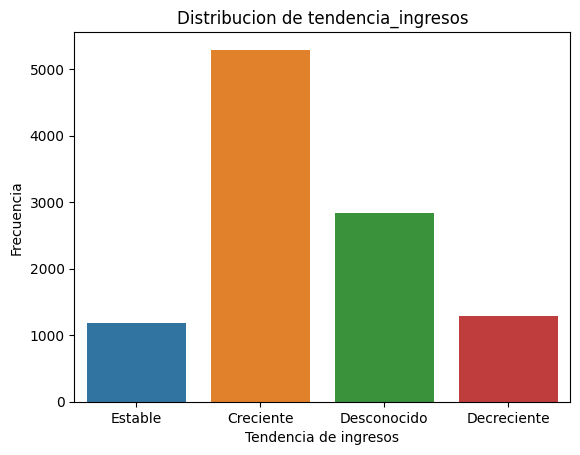

In [63]:
sns.countplot(data=df, x='tendencia_ingresos', hue='tendencia_ingresos', legend=False)
plt.title('Distribucion de tendencia_ingresos')
plt.xlabel('Tendencia de ingresos')
plt.ylabel('Frecuencia')
plt.show()

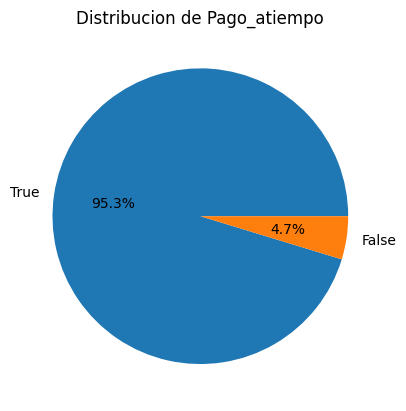

In [64]:
df['Pago_atiempo'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Distribucion de Pago_atiempo')
plt.ylabel('')
plt.show()

In [65]:
columnas_numericas = ['edad_cliente', 'salario_cliente', 'capital_prestado', 'cuota_pactada', 
                       'plazo_meses', 'puntaje', 'puntaje_datacredito', 'cant_creditosvigentes',
                       'huella_consulta', 'saldo_mora', 'saldo_total', 'saldo_principal', 
                       'saldo_mora_codeudor', 'creditos_sectorFinanciero', 'creditos_sectorCooperativo',
                       'creditos_sectorReal', 'promedio_ingresos_datacredito']

resumen = df[columnas_numericas].agg(['mean', 'median', lambda x: x.mode()[0], 'min', 'max', 'var', 'std', 'skew', 'kurt']).T
resumen.columns = ['media', 'mediana', 'moda', 'min', 'max', 'varianza', 'desv_std', 'skewness', 'kurtosis']
resumen['rango'] = resumen['max'] - resumen['min']
resumen

,media,mediana,moda,min,max,varianza,desv_std,skewness,kurtosis,rango
edad_cliente,4.285007e+01,4.200000e+01,4.000000e+01,19.00000,6.900000e+01,1.428198e+02,1.195073e+01,0.266694,-0.861835,5.000000e+01
salario_cliente,4.023870e+06,3.000000e+06,3.000000e+06,0.00000,1.035000e+09,1.176096e+14,1.084480e+07,81.642187,7710.943249,1.035000e+09
capital_prestado,2.385874e+06,1.903639e+06,1.200000e+06,360000.00000,2.880000e+07,3.119770e+12,1.766287e+06,2.603197,13.726995,2.844000e+07
cuota_pactada,2.385256e+05,1.811400e+05,2.059900e+05,23944.00000,2.671342e+06,3.912129e+10,1.977910e+05,3.323429,18.521937,2.647398e+06
plazo_meses,1.059811e+01,1.000000e+01,6.000000e+00,2.00000,9.000000e+01,4.443711e+01,6.666117e+00,2.444681,7.661835,8.800000e+01
puntaje,9.121603e+01,9.522779e+01,9.522779e+01,-38.00999,9.522779e+01,2.668570e+02,1.633576e+01,-4.884122,24.296813,1.332378e+02
puntaje_datacredito,7.914637e+02,7.920000e+02,7.830000e+02,-7.00000,9.990000e+02,2.707157e+03,5.203034e+01,-1.297390,14.632049,1.006000e+03
cant_creditosvigentes,5.807449e+00,5.000000e+00,4.000000e+00,0.00000,6.200000e+01,1.558269e+01,3.947491e+00,1.847538,8.939327,6.200000e+01
huella_consulta,4.287223e+00,4.000000e+00,2.000000e+00,0.00000,2.900000e+01,9.269061e+00,3.044513e+00,1.518486,4.119599,2.900000e+01
saldo_mora,6.778166e+00,0.000000e+00,0.000000e+00,0.00000,1.253400e+04,4.104931e+04,2.026063e+02,43.864143,2224.744514,1.253400e+04


### Resumen estadistico de variables numericas

Se calculan las principales medidas de tendencia central y dispersion para todas las variables numericas. 
Se destaca:

- La mayoria de las variables presentan skewness y kurtosis muy altos, indicando distribuciones con cola larga y presencia de outliers (ya identificados y tratados en gran parte anteriormente).

- Se detecta un valor minimo negativo en `puntaje_datacredito` (-7), lo cual se investiga a continuacion.

In [66]:
print("Casos con puntaje_datacredito negativo:", (df['puntaje_datacredito'] < 0).sum())
df[df['puntaje_datacredito'] < 0]

Casos con puntaje_datacredito negativo: 1


,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,...,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
928,9,2025-03-22 12:25:00,2602506,10,69.0,Independiente,8000000.0,2000000,221080,91.410695,...,NaN,NaN,NaN,NaN,0,0,0,21307677.0,Desconocido,True


In [67]:
print("Total de casos negativos:", (df['puntaje_datacredito'] < 0).sum())
df.loc[df['puntaje_datacredito'] < 0, 'puntaje_datacredito'] = np.nan

Total de casos negativos: 1


### Valor negativo en puntaje_datacredito

Se detecta 1 registro con puntaje_datacredito = -7, valor imposible para una escala de puntaje. El resto de la fila no presenta inconsistencias, por lo que se convierte unicamente este valor a 'nulo', sin afectar el resto.

### Resto de variables numericas

El resto de las variables numericas (saldos, creditos por sector, huella_consulta, promedio_ingresos_datacredito) fueron revisadas en la tabla estadistica general. 

No se identifican hallazgos adicionales que requieran correccion, mas alla de los nulos ya documentados al inicio del analisis.

## Analisis Bivariables

### tipo_laboral vs pago_atiempo

In [68]:
pd.crosstab(df['tipo_laboral'], df['Pago_atiempo'], normalize='index')

Pago_atiempo,False,True
tipo_laboral,,
Empleado,0.042292,0.957708
Independiente,0.055140,0.944860


Empleado:       95.77% paga a tiempo (4.23% no paga)
Independiente:  94.49% paga a tiempo (5.51% no paga)

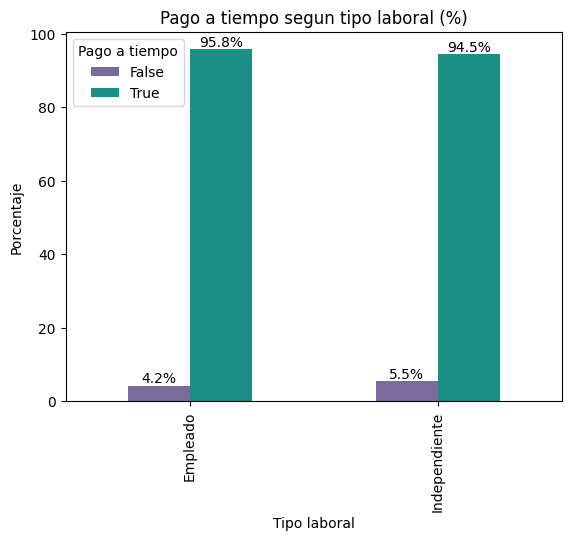

In [69]:
tabla = pd.crosstab(df['tipo_laboral'], df['Pago_atiempo'], normalize='index') * 100

ax = tabla.plot(kind='bar', color=['#796C9D', "#1A8F85"])
plt.title('Pago a tiempo segun tipo laboral (%)')
plt.xlabel('Tipo laboral')
plt.ylabel('Porcentaje')
plt.legend(title='Pago a tiempo')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.show()

### tendencia_ingresos vs Pago_atiempo 

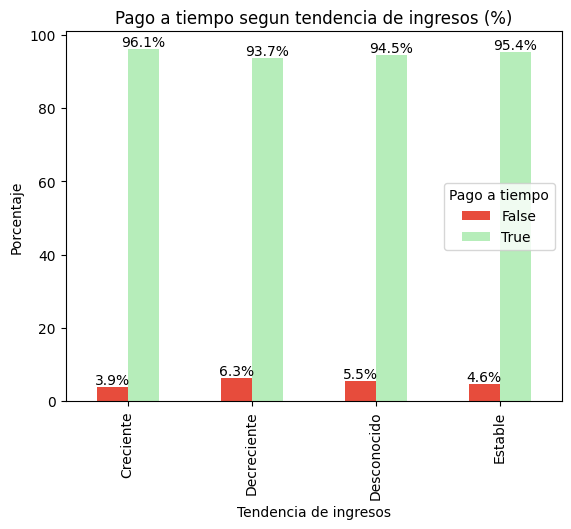

In [70]:
tabla2 = pd.crosstab(df['tendencia_ingresos'], df['Pago_atiempo'], normalize='index') * 100

ax = tabla2.plot(kind='bar', color=['#E74C3C', "#ACEBB0DF"])
plt.title('Pago a tiempo segun tendencia de ingresos (%)')
plt.xlabel('Tendencia de ingresos')
plt.ylabel('Porcentaje')
plt.legend(title='Pago a tiempo')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.show()

### Pago a tiempo segun tendencia de ingresos

La categoria `Decreciente` presenta el mayor porcentaje de incumplimiento (6.3%), mientras que `Creciente` presenta el menor (3.9%). El resto de las categorias se mantiene en valores intermedios similares.

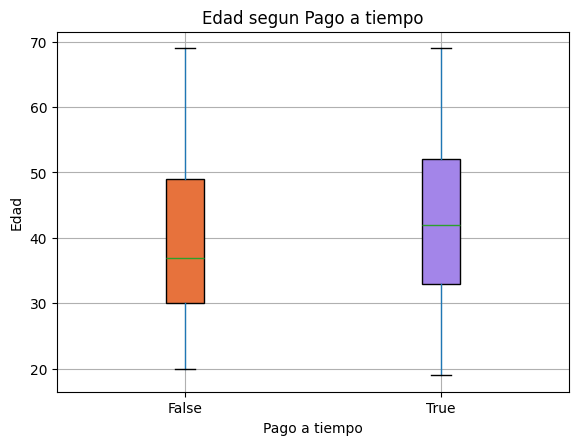

In [71]:
caja = df.boxplot(column='edad_cliente', by='Pago_atiempo', patch_artist=True,
                   boxprops=dict(facecolor='lightblue'))

# Coloreamos cada caja individualmente
colores = ["#E7723C", '#A385E9']
for patch, color in zip(caja.patches, colores):
    patch.set_facecolor(color)

plt.title('Edad segun Pago a tiempo')
plt.suptitle('')
plt.xlabel('Pago a tiempo')
plt.ylabel('Edad')
plt.show()

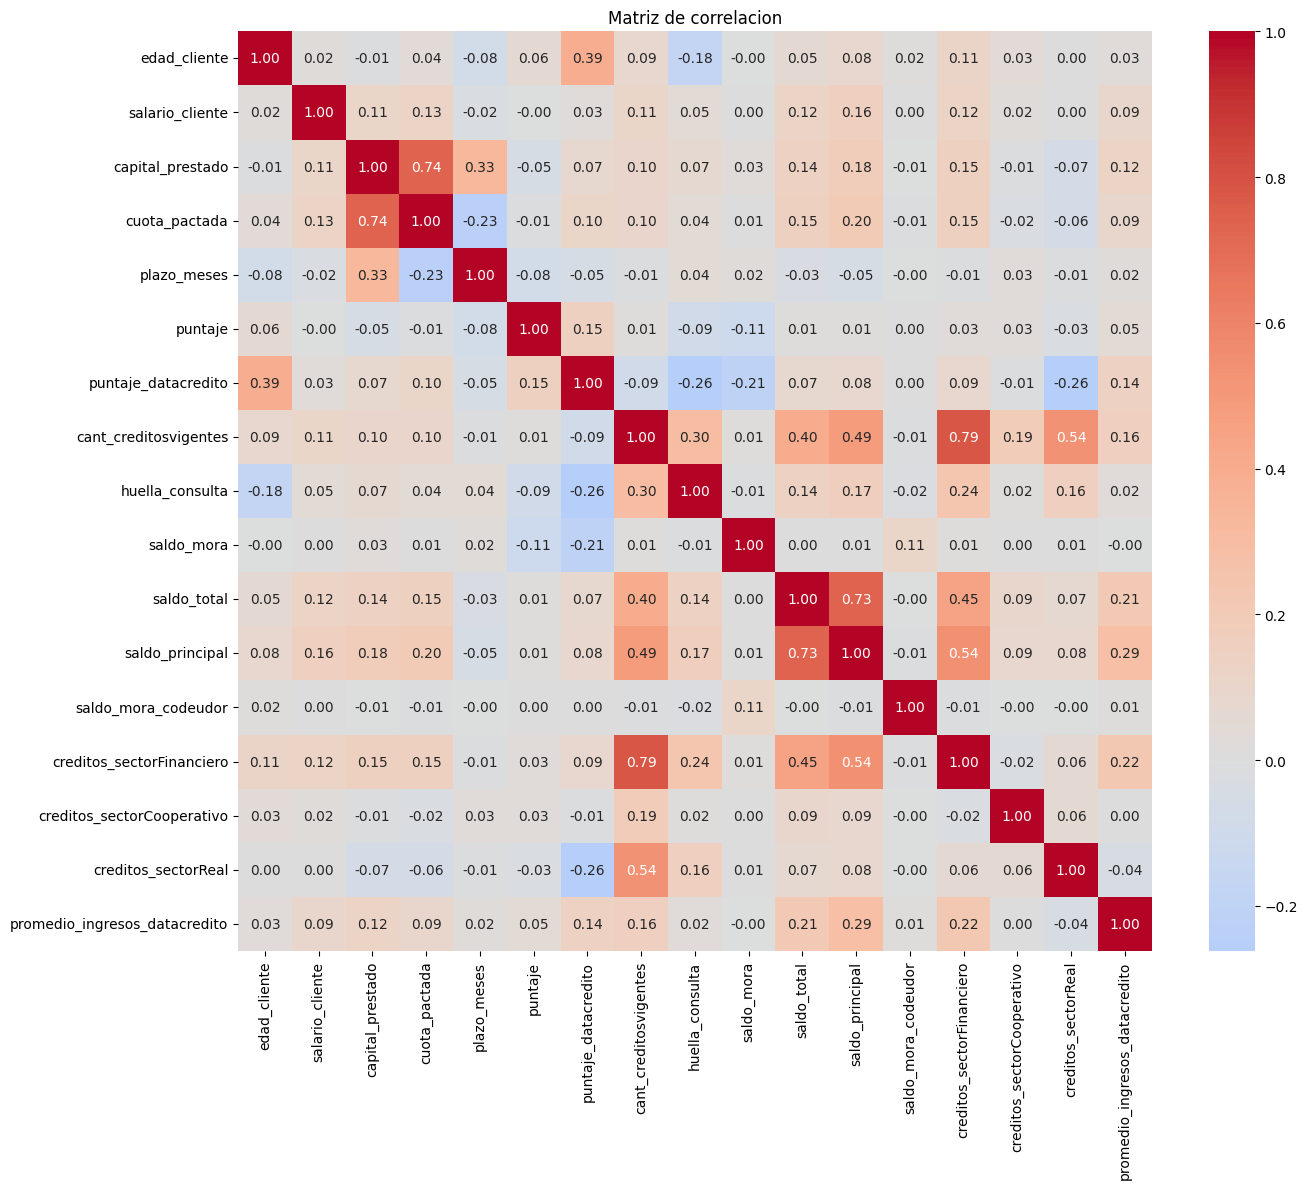

In [72]:
plt.figure(figsize=(14, 12))
sns.heatmap(df[columnas_numericas].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matriz de correlacion')
plt.tight_layout()
plt.show()

### Matriz de correlacion

Se destacan correlaciones fuertes y logicas: capital_prestado con cuota_pactada (0.74), saldo_total con saldo_principal (0.73), y cant_creditosvigentes con creditos_sectorFinanciero (0.79), esta ultima la mas alta de la matriz. Tambien se observa una correlacion moderada entre edad_cliente y puntaje_datacredito (0.39), sugiriendo que clientes mayores tienden a tener mejor historial crediticio.

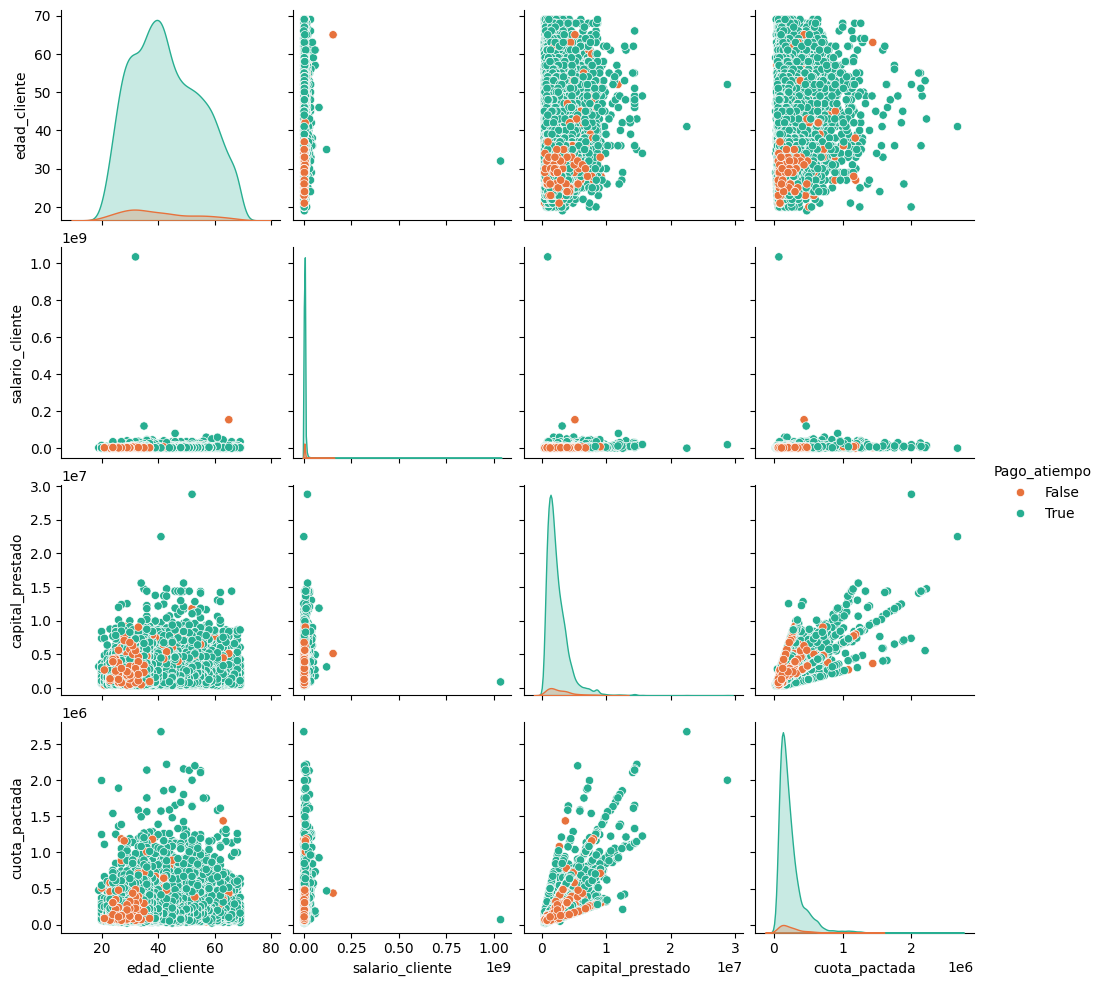

In [74]:
columnas_clave = ['edad_cliente', 'salario_cliente', 'capital_prestado', 'cuota_pactada', 'Pago_atiempo']
sns.pairplot(df[columnas_clave].dropna(), hue='Pago_atiempo', 
             palette={False:"#E7723C", True: "#27AE91"})
plt.show()

In [75]:
df[df['salario_cliente'] > 500_000_000]

,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,...,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
9832,4,2025-01-17 15:42:00,907200,12,32.0,Empleado,1.035000e+09,400000,70948,95.227787,...,0.0,6097.0,6097.0,0.0,1,2,1,846374.0,Creciente,True


In [76]:
fila_outlier = df[df['salario_cliente'] > 500_000_000]
print("Cantidad de filas encontradas:", len(fila_outlier))
print("Indice(s):", fila_outlier.index.tolist())
fila_outlier

Cantidad de filas encontradas: 1
Indice(s): [9832]


,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,...,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
9832,4,2025-01-17 15:42:00,907200,12,32.0,Empleado,1.035000e+09,400000,70948,95.227787,...,0.0,6097.0,6097.0,0.0,1,2,1,846374.0,Creciente,True


### Reemplazo puntual: salario_cliente del cliente indice 9832

Se identifica un unico registro (indice 9832) con salario_cliente = 1.035.000.000, un valor incoherente con el resto de sus datos (promedio_ingresos_datacredito de 846.374, capital prestado de 907.200). Se reemplaza unicamente el valor de salario_cliente de esta fila puntual por nulo, sin aplicar ninguna regla general ni afectar otras filas del dataset.

In [77]:
print("Valor de salario_cliente ANTES del cambio (indice 9832):", df.loc[9832, 'salario_cliente'])

df.loc[9832, 'salario_cliente'] = np.nan

print("Valor de salario_cliente DESPUES del cambio (indice 9832):", df.loc[9832, 'salario_cliente'])

Valor de salario_cliente ANTES del cambio (indice 9832): 1035000000.0
Valor de salario_cliente DESPUES del cambio (indice 9832): nan


Esto usa df.loc[9832, ...] — apunta únicamente a la fila con ese número de índice exacto, sin ninguna condición que pueda afectar a otras filas

In [78]:
df.loc[[9832]]

,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,...,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
9832,4,2025-01-17 15:42:00,907200,12,32.0,Empleado,NaN,400000,70948,95.227787,...,0.0,6097.0,6097.0,0.0,1,2,1,846374.0,Creciente,True


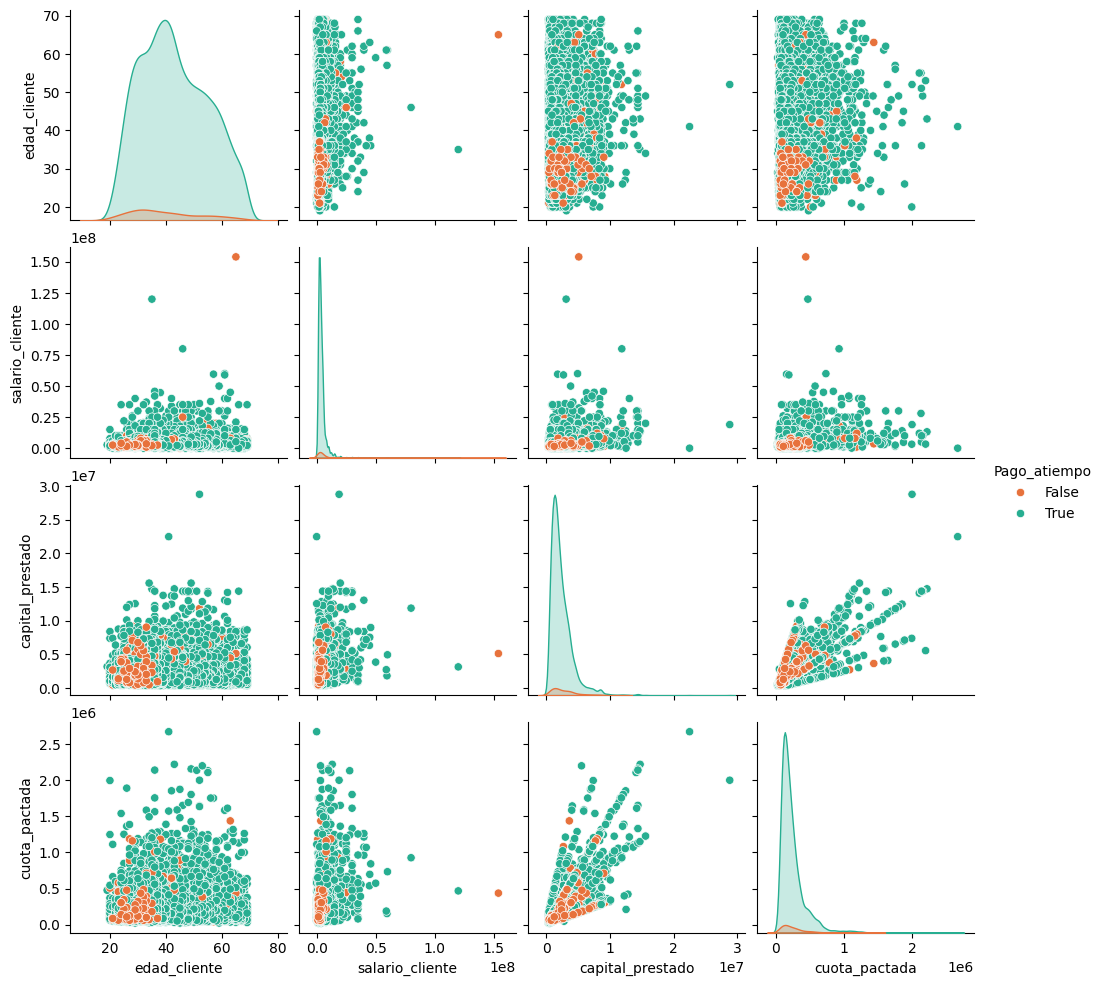

In [79]:
columnas_clave = ['edad_cliente', 'salario_cliente', 'capital_prestado', 'cuota_pactada', 'Pago_atiempo']
sns.pairplot(df[columnas_clave].dropna(), hue='Pago_atiempo', 
             palette={False:"#E7723C", True: "#27AE91"})
plt.show() 

### Pairplot actualizado (post correccion de salario_cliente)

Tras corregir el registro con salario incoherente (indice 9832) la escala del grafico mejora notablemente. Persisten 2 casos de salario alto (120 y 154 millones), ya evaluados previamente sin evidencia de error por lo que se mantienen sin modificar.

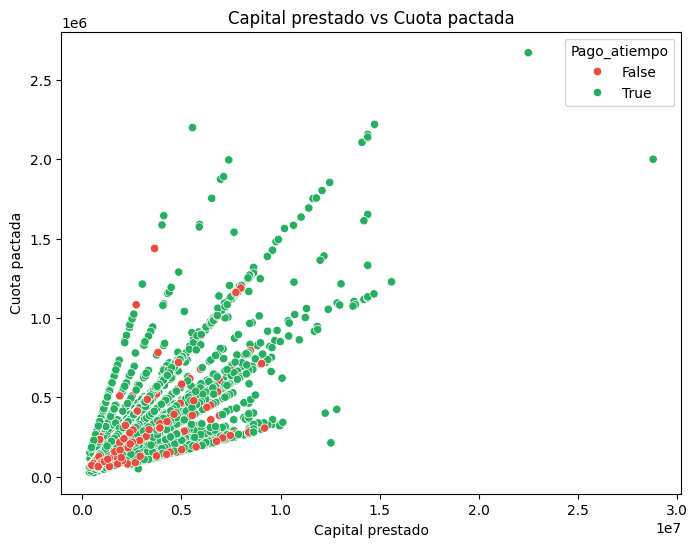

In [80]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='capital_prestado', y='cuota_pactada', hue='Pago_atiempo',
                 palette={False: '#E74C3C', True: '#27AE60'})
plt.title('Capital prestado vs Cuota pactada')
plt.xlabel('Capital prestado')
plt.ylabel('Cuota pactada')
plt.show()

### Capital prestado vs Cuota pactada

Se confirma la relacion lineal entre ambas variables. Los casos de incumplimiento (Pago_atiempo = False) se concentran mayormente en montos de capital prestado mas bajos sin una separacion clara respecto a los casos de pago a tiempo.

## Conclusiones del EDA

### Reglas de validacion de datos identificadas

- `edad_cliente`: valores fuera del rango 18-90 anos deben considerarse invalidos.
- `salario_cliente`: valores que superen ampliamente el promedio_ingresos_datacredito 
de la misma persona (o superen un umbral como 100 millones) deben revisarse antes 
de usarse.
- `puntaje_datacredito`: valores negativos son invalidos, dado que se trata de una 
escala de puntaje.
- `tendencia_ingresos`: solo se aceptan los valores Creciente, Decreciente, Estable 
o Desconocido; cualquier otro valor (numerico, por ejemplo) debe tratarse como dato 
faltante.
- Bloques de registros con multiples columnas inconsistentes simultaneamente (edad, 
salario, capital) deben tratarse como errores sistematicos de carga, no como 
variabilidad real.

### Transformaciones identificadas

- Convertir `fecha_prestamo` en columnas separadas (anio, mes, hora) para uso en 
feature engineering.
- Codificar `tipo_credito` como variable categorica (no ordinal), dado que no se 
cuenta con diccionario de significado de los codigos.
- Aplicar imputacion (media o mediana) en columnas numericas con nulos remanentes 
(saldos, promedio_ingresos_datacredito).

### Atributos adicionales que podrian ser utiles

- Relacion cuota_pactada / salario_cliente: para medir la carga financiera relativa 
de cada cliente.
- Antiguedad del prestamo (dias desde fecha_prestamo hasta la fecha actual).
- Indicador binario de si el cliente tiene tendencia_ingresos = Desconocido, dado 
que podria representar informacion util por si misma.

parte Avance 2

In [81]:
print(df['tendencia_ingresos'].value_counts())
print(df['tendencia_ingresos'].value_counts(normalize=True) * 100)

tendencia_ingresos
Creciente      5290
Desconocido    2836
Decreciente    1291
Estable        1188
Name: count, dtype: int64
tendencia_ingresos
Creciente      49.882131
Desconocido    26.742103
Decreciente    12.173503
Estable        11.202263
Name: proportion, dtype: float64


### Tratamiento de `tendencia_ingresos` como variable ordinal

A diferencia del resto de las variables categoricas, `tendencia_ingresos` tiene un **orden logico** entre sus valores, por lo que se decidio codificarla con `OrdinalEncoder` en lugar de `OneHotEncoder`.

**Distribucion de la variable:**

| Categoria    | Cantidad | Porcentaje |
|--------------|---------:|-----------:|
| Creciente    | 5290     | 49.9%      |
| Desconocido  | 2836     | 26.7%      |
| Decreciente  | 1291     | 12.2%      |
| Estable      | 1188     | 11.2%      |

**Decision sobre `Desconocido`:** representa un 26.7% del total, un porcentaje
demasiado alto como para descartarlo o reasignarlo a otra categoria sin introducir
sesgo. Por eso se mantiene como categoria propia, ubicada en el extremo neutro del
orden definido:

Desconocido (0) -> Decreciente (1) -> Estable (2) -> Creciente (3)

Esta codificacion conserva la relacion de orden real entre Decreciente, Estable y Creciente, sin forzar una interpretacion erronea para los registros sin informacion disponible.

In [82]:
categorias_validas = ['Creciente', 'Decreciente', 'Estable', 'Desconocido']
print(df['tendencia_ingresos'].unique())
print(df[~df['tendencia_ingresos'].isin(categorias_validas)].shape[0])

['Estable' 'Creciente' 'Desconocido' 'Decreciente']
0
